In [3]:
import pysam
import matplotlib.pyplot as plt
import tinycov


In [2]:
# Imports & Configuration 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import glob

# --- Configuration ---
CONFIG = {
    'variant_pattern': "/mnt/claw-raid/elliot/P003_mtDeepSeq/results/3842/variants.annotatedCell*.txt",
    'haplo_pattern': "/mnt/claw-raid/elliot/P003_mtDeepSeq/results/3842/haplogroupsCell*.txt",
    'min_coverage': 500,
    'min_heteroplasmy': 1.0,
    'haplo_alt_allele_threshold': 95.0,
    'output_base': 'variant_distribution'
}

print("✅ Configuration loaded")


✅ Configuration loaded


/tmp/ipykernel_1877712/539178683.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=8, ncol=2, title="Cells")


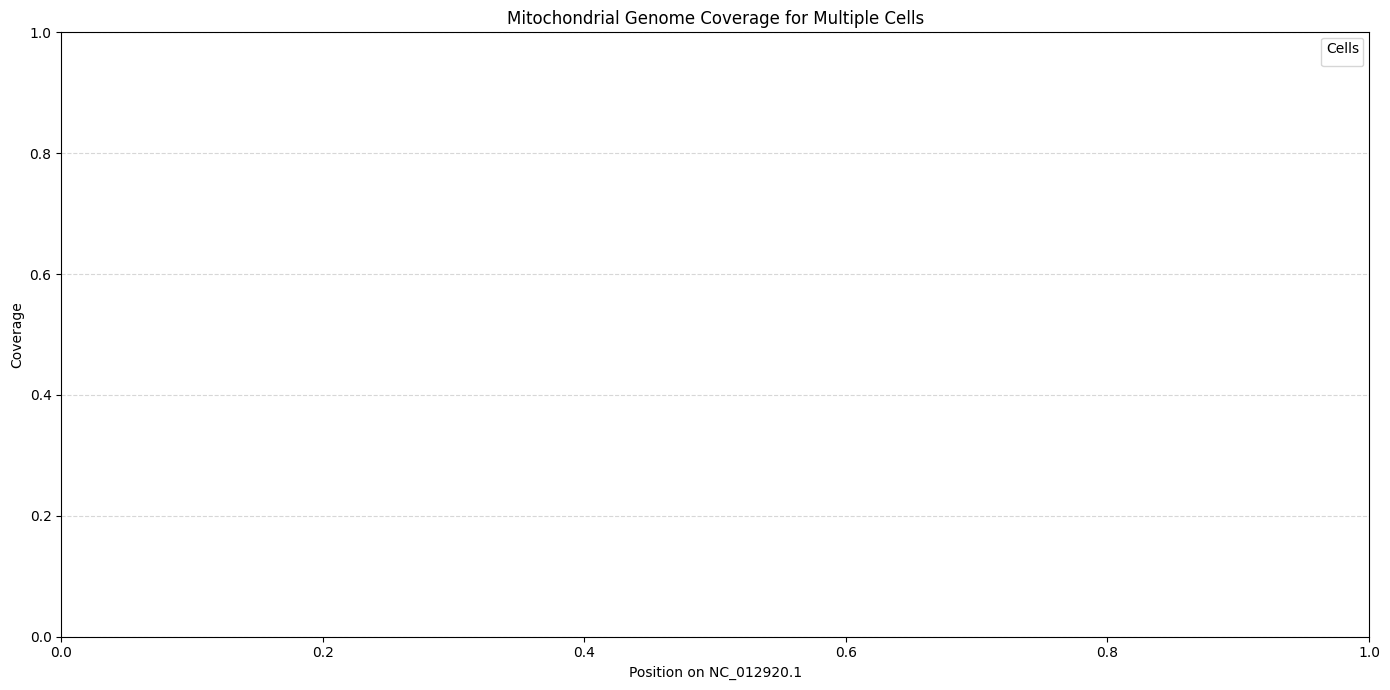

In [3]:
import pysam
import matplotlib.pyplot as plt
import glob
import os
import re

# Directory containing BAM files
bam_dir = "/mnt/claw-raid/elliot/P003/data/3842"
chrom = "NC_012920.1"  # mitochondrial genome

# Find all sorted BAM files matching the pattern
bam_files = sorted(glob.glob(os.path.join(bam_dir, "3842_*_sorted.bam")))

plt.figure(figsize=(14, 7))

for bam_path in bam_files:
    # Extract cell number from filename
    match = re.search(r"3842_(\d+)_sorted\.bam", os.path.basename(bam_path))
    label = f"Cell{match.group(1)}" if match else os.path.basename(bam_path)
    
    bam = pysam.AlignmentFile(bam_path, "rb")
    mt_length = bam.get_reference_length(chrom)
    coverage = [sum(x) for x in zip(*bam.count_coverage(chrom, start=0, end=mt_length))]
    bam.close()
    
    plt.plot(coverage, label=label, linewidth=1)

plt.title("Mitochondrial Genome Coverage for Multiple Cells")
plt.xlabel("Position on NC_012920.1")
plt.ylabel("Coverage")
plt.legend(fontsize=8, ncol=2, title="Cells")
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Removed the plt.yticks() line that was forcing specific tick marks
plt.tight_layout()
plt.show()

In [4]:
# === Cell 2: Helper Functions ===

def extract_cell_id(filepath):
    """Extract cell ID from filename (e.g., 'Cell001')."""
    match = re.search(r"Cell(\d+)", Path(filepath).name)
    return f"Cell{int(match.group(1)):03d}" if match else None


def load_variants(filepath):
    """Load and process a variant file."""
    df = pd.read_csv(filepath, sep='\t')

    # Ensure numeric
    df['variant_level'] = pd.to_numeric(df['VariantLevel'], errors='coerce')
    df['coverage'] = pd.to_numeric(df['Coverage'], errors='coerce')
    df['Pos'] = pd.to_numeric(df.get('Pos', np.nan), errors='coerce')

    df = df.dropna(subset=['variant_level', 'coverage'])

    # SIMPLE FIX: Check if values need scaling
    sample_values = df['variant_level'].head(5)  # Check first 5 values
    if all(0 <= v <= 1 for v in sample_values if not pd.isna(v)):
        df['variant_level'] = df['variant_level'] * 100
        print(f"   Scaled heteroplasmy values to percentage for {Path(filepath).name}")

    # Add identifiers
    df['pos_allele'] = df['Pos'].astype(str) + df['Variant'].str.upper()
    df['gene'] = df.get('Maplocus', 'Unknown')
    df['complex'] = df.get('OXPHOS_complex', '').fillna('Non-coding').replace('', 'Non-coding')

    return df


def get_haplogroup_variants(filepath):
    """Extract haplogroup variants (e.g., 1234A) from a haplogroup file."""
    try:
        df = pd.read_csv(filepath, sep='\t')
        variants = set()
        for col in ['Found_Polys', 'Remaining_Polys']:
            if col in df.columns:
                for val in df[col].dropna():
                    variants.update(re.findall(r'\d+[ACGT]', str(val).upper()))
        return variants
    except Exception:
        return set()





In [5]:
# === Load and process variants with haplogroup marker flipping ===
variant_files = sorted(glob.glob(CONFIG['variant_pattern']))
haplo_files = {extract_cell_id(f): f for f in glob.glob(CONFIG['haplo_pattern'])}
all_data, all_cells = [], []

for vf in variant_files:
    cell_id = extract_cell_id(vf)
    if not cell_id:
        continue
    
    df = load_variants(vf)
    df['cell_id'] = cell_id
    df['is_flipped'] = False
    df['original_variant_level'] = df['variant_level'].copy()
    
    # Apply coverage filter
    df = df[df['coverage'] >= CONFIG['min_coverage']]
    
    # Flip haplogroup markers >95%
    if cell_id in haplo_files:
        haplo_vars = get_haplogroup_variants(haplo_files[cell_id])
        should_flip = df['pos_allele'].isin(haplo_vars) & (df['variant_level'] > 95.0)
        df.loc[should_flip, 'variant_level'] = 100 - df.loc[should_flip, 'variant_level']
        df.loc[should_flip, 'is_flipped'] = True
    
    # Apply VAF filter (keep flipped variants even if <1%)
    df = df[(df['variant_level'] >= 1.0) | (df['is_flipped'] == True)]
    
    if len(df) > 0:
        all_data.append(df)
        all_cells.append(cell_id)

df_all = pd.concat(all_data, ignore_index=True)
print(f"Processed {len(all_cells)} cells, {len(df_all)} variants ({df_all['is_flipped'].sum()} flipped)")

   Scaled heteroplasmy values to percentage for variants.annotatedCell001.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell003.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell004.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell006.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell007.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell009.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell010.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell011.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell012.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell013.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell015.txt
   Scaled heteroplasmy values to percentage for variants.annotatedCell017.txt
   Scaled heteroplasmy values to percentage for variants.annotat

/tmp/ipykernel_1877712/50529584.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df_all.groupby('het_bin')['cell_id'].nunique().reindex(bin_labels, fill_value=0)



=== Cells per Heteroplasmy Bin ===
Heteroplasmy Bin  Cells with Variants in Bin
           1-10%                          17
          10-20%                          14
          20-30%                           1
          30-40%                           2
          40-50%                           1
          50-60%                           1
          60-70%                           1
          70-80%                           0
          80-90%                           1
         90-100%                           7


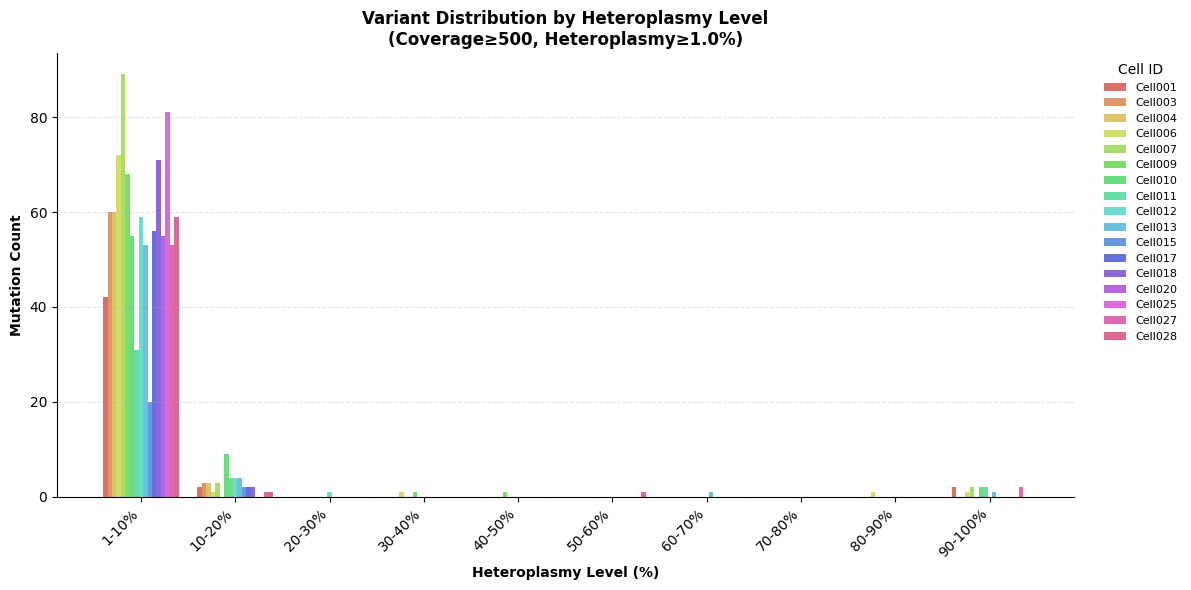

In [6]:
import seaborn as sns
import pandas as pd
import numpy as np

# === Cell 4: Plot 1 — Heteroplasmy Distribution + Cell Count Table ===

# Define bins directly in plotting code instead of CONFIG
bins = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
bin_labels = [f"{bins[i]}-{bins[i+1]}%" 
              for i in range(len(bins) - 1)]

df_all['het_bin'] = pd.cut(df_all['variant_level'],
                           bins=bins, 
                           labels=bin_labels,
                           include_lowest=True)

mutation_counts = df_all.groupby(['cell_id', 'het_bin'], observed=True).size().unstack(fill_value=0)
mutation_counts = mutation_counts.reindex(columns=bin_labels, fill_value=0)
mutation_counts = mutation_counts.reindex(index=all_cells, fill_value=0)

# NEW: Cell count table by bin
cell_counts = df_all.groupby('het_bin')['cell_id'].nunique().reindex(bin_labels, fill_value=0)
cell_counts = pd.DataFrame({'Heteroplasmy Bin': bin_labels, 'Cells with Variants in Bin': cell_counts.values})
print("\n=== Cells per Heteroplasmy Bin ===")
print(cell_counts.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
n_cells = len(mutation_counts)
colors = sns.color_palette("hls", n_cells)

x = np.arange(len(bin_labels))
width = 0.8 / n_cells

for i, cell_id in enumerate(mutation_counts.index):
    offset = (i - n_cells / 2) * width + width / 2
    ax.bar(x + offset, mutation_counts.loc[cell_id], width=width,
           label=cell_id, color=colors[i % len(colors)], alpha=0.9)

ax.set_xlabel('Heteroplasmy Level (%)', fontweight='bold')
ax.set_ylabel('Mutation Count', fontweight='bold')
ax.set_title(f'Variant Distribution by Heteroplasmy Level\n(Coverage≥{CONFIG["min_coverage"]}, Heteroplasmy≥{CONFIG["min_heteroplasmy"]}%)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.legend(title='Cell ID', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig("variant_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


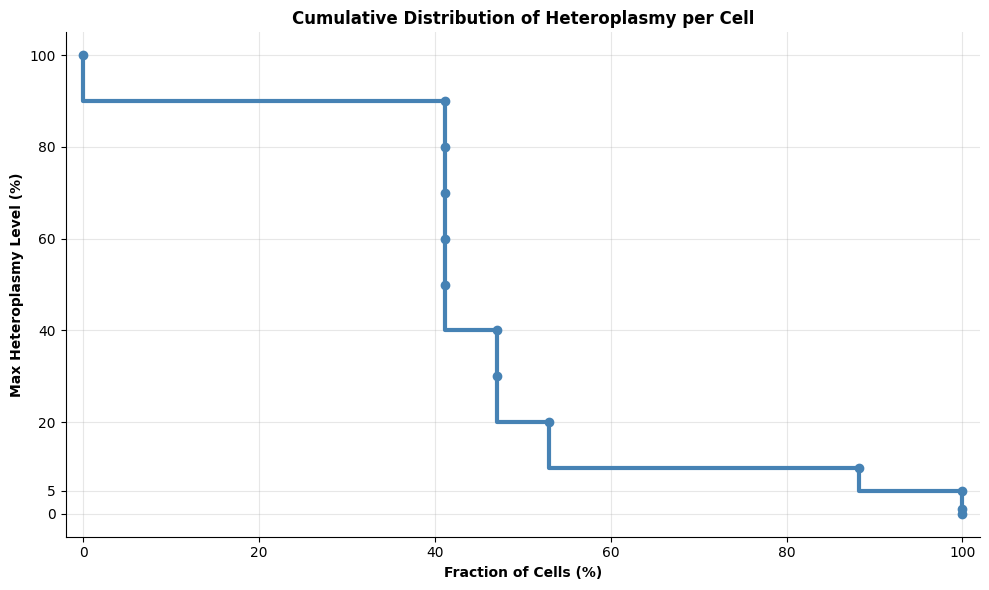

NameError: name 'df_table' is not defined

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

thresholds = np.array([0,1,5,10,20,30,40,50,60,70,80,90,100])
pcts = [(df_all.groupby('cell_id')['variant_level'].max() >= t).mean()*100 for t in thresholds]

plt.figure(figsize=(10,6))
plt.step(pcts, thresholds, where='post', lw=3, marker='o', color='steelblue')
plt.xlabel('Fraction of Cells (%)', fontweight='bold')
plt.ylabel('Max Heteroplasmy Level (%)', fontweight='bold')
plt.title('Cumulative Distribution of Heteroplasmy per Cell', fontweight='bold')
plt.yticks(thresholds[::2])
plt.xlim(-2, 102)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("cumulative_heteroplasmy.png", dpi=300, bbox_inches='tight')
plt.show()

print(df_table.to_string(index=False))


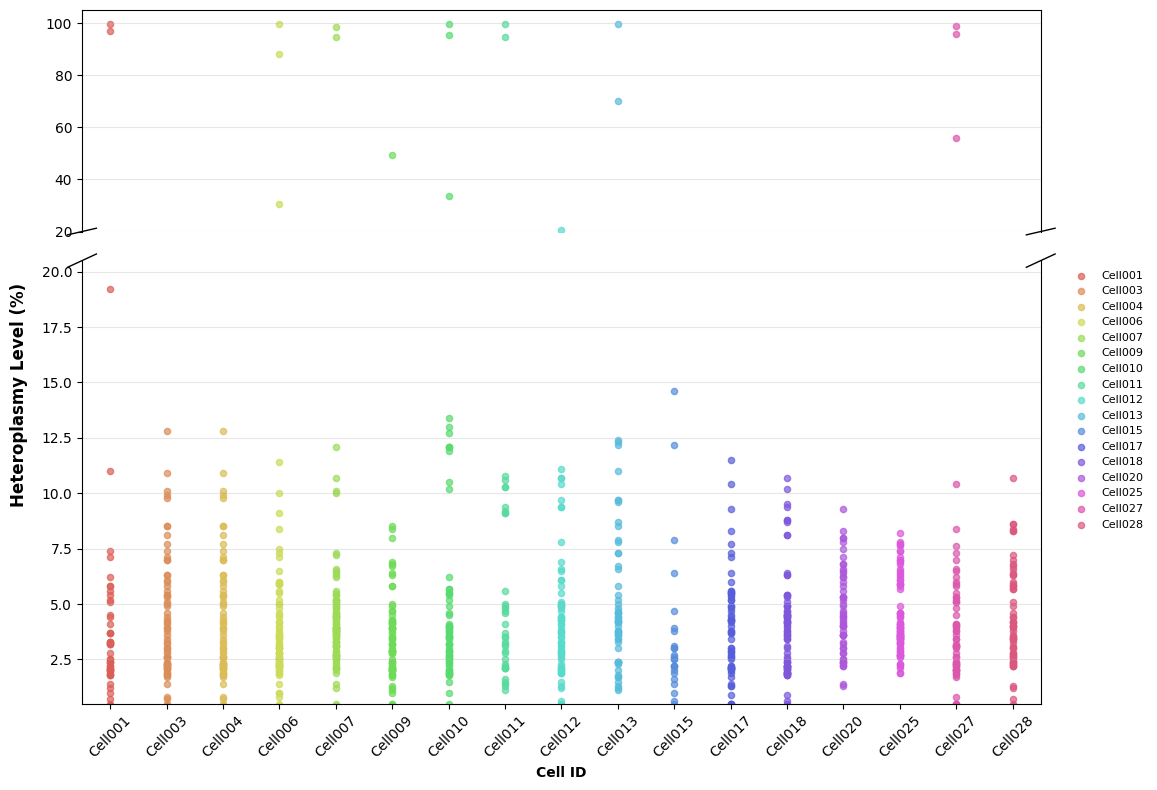

In [ ]:
# === Nature-style Broken Axis Heteroplasmy Plot ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), 
                               gridspec_kw={'height_ratios': [1, 2]})
n_cells = len(all_cells)
colors = sns.color_palette("hls", n_cells)

# Plot both ranges
for i, cell_id in enumeratl_data['variant_level'] > 20]
    ax1.scatter([i] * len(high_het), high_het['variant_level'], 
                color=colors[i % len(colors)], alpha=0.7, s=20)

# Set consistent x-limits for both plots
x_min, x_max = -0.5, len(all_cells) - 0.5
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)

# Configure top plot (20-100%)
ax1.set_ylim(20, 105)
ax1.spines['bottom'].set_visible(False)
ax1.tick_params(bottom=False, labelbottom=False)
ax1.grid(True, alpha=0.3, axis='y')  # Only y-grid for consiste(all_cells):
    cell_data = df_all[df_all['cell_id'] == cell_id]
    
    # Low heteroplasmy (1-20%)
    low_het = cell_data[cell_data['variant_level'] <= 20]
    ax2.scatter([i] * len(low_het), low_het['variant_level'], 
                color=colors[i % len(colors)], alpha=0.7, s=20, label=cell_id)
    
    # High heteroplasmy (20-100%)  
    high_het = cell_data[celency

# Configure bottom plot (1-20%)
ax2.set_ylim(0.5, 20.5)
ax2.spines['top'].set_visible(False)
ax2.set_xlabel('Cell ID', fontweight='bold')
ax2.set_xticks(range(len(all_cells)))
ax2.set_xticklabels(all_cells, rotation=45)
ax2.grid(True, alpha=0.3, axis='y')  # Only y-grid for consistency

# Single y-axis label for both plots
fig.text(0.04, 0.5, 'Heteroplasmy Level (%)', va='center', rotation='vertical', fontweight='bold', fontsize=12)

# Proper diagonal break marks
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
ax1.plot((-d, d), (-d, d), **kwargs)        # bottom-left
ax1.plot((1-d, 1+d), (-d, d), **kwargs)     # bottom-right

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, d), (1-d, 1+d), **kwargs)     # top-left
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)  # top-right

ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(left=0.1)
plt.show()

/tmp/ipykernel_947328/719741274.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20')


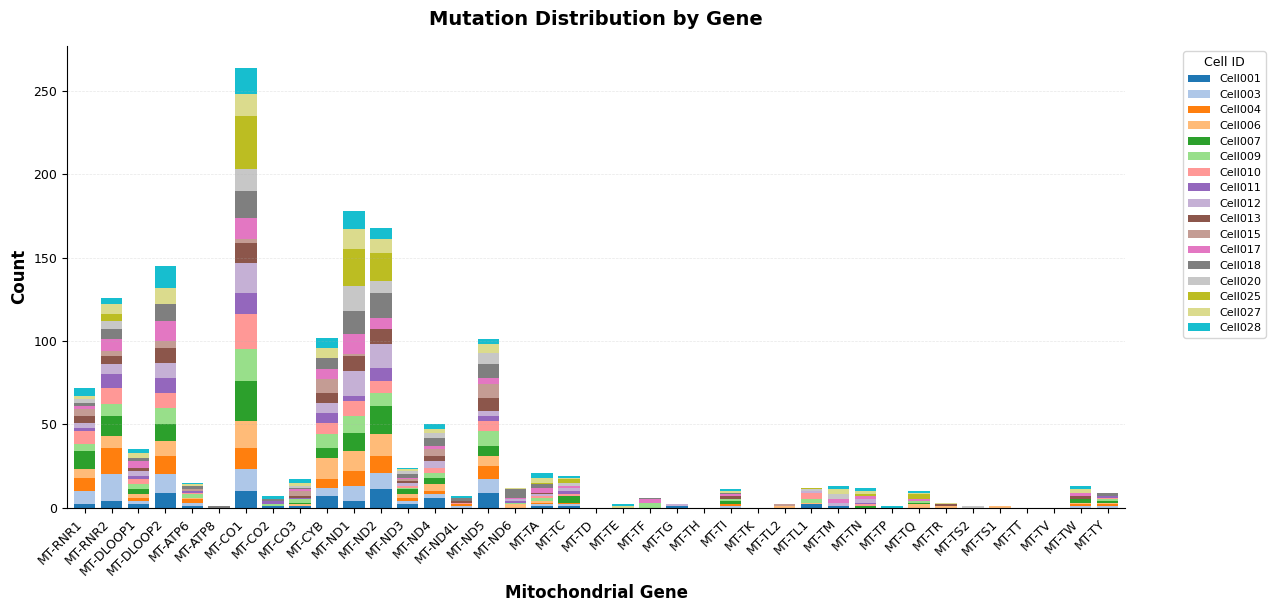

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Generate a nice color palette
def generate_colors(n):
    """Generate visually distinct colors"""
    cmap = plt.cm.get_cmap('tab20')
    if n > 20:
        cmap = plt.cm.get_cmap('hsv')
    return [cmap(i/n) for i in range(n)]

fig, ax = plt.subplots(figsize=(max(12, len(gene_counts.columns) * 0.35), 6))

# Get colors for each cell
colors = generate_colors(len(gene_counts))

# Plot with custom colors
gene_counts.T.plot(
    kind='bar', 
    stacked=True, 
    ax=ax,
    width=0.8,
    color=colors,
    edgecolor='none'
)

# Styling
ax.set_title('Mutation Distribution by Gene', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mitochondrial Gene', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')

# Legend
ax.legend(
    title='Cell ID',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=True,
    fontsize=8,
    title_fontsize=9
)

# Clean up axes
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Light grid on y-axis only
ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

/tmp/ipykernel_947328/1439408395.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20')


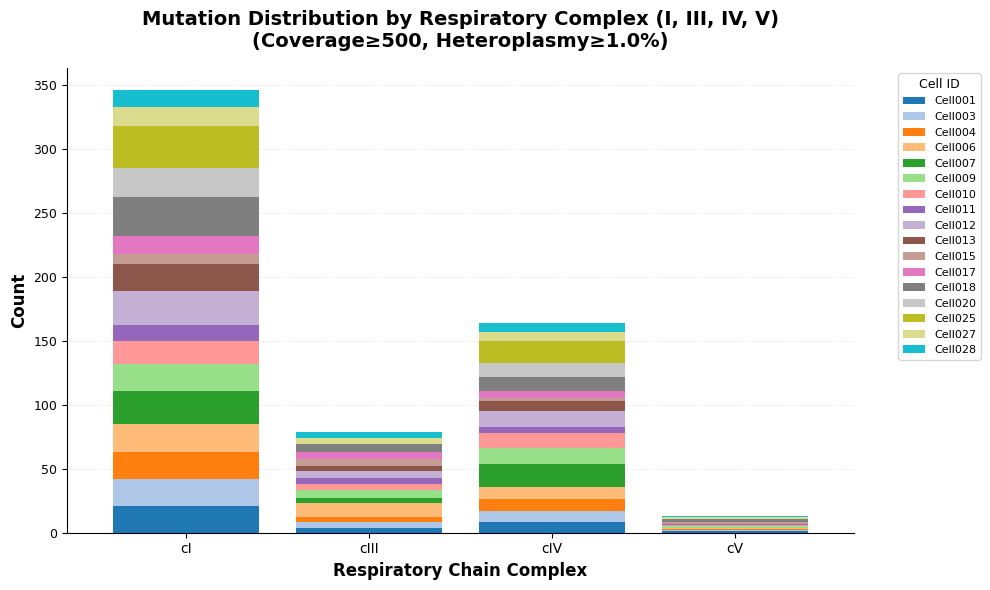

In [18]:
# Generate nice colors
def generate_colors(n):
    cmap = plt.cm.get_cmap('tab20')
    if n > 20:
        cmap = plt.cm.get_cmap('hsv')
    return [cmap(i/n) for i in range(n)]

# Filter only variants in OXPHOS complex genes (I, III, IV, V)
df_resp = df_all[df_all['OXPHOS_complex'].notna()].copy()
if df_resp.empty:
    print("⚠️ No variants affecting respiratory complex proteins in filtered data.")
else:
    # Use the OXPHOS_complex column directly
    df_resp['complex'] = df_resp['OXPHOS_complex']
    
    # Standardize complex naming to match your expected format
    complex_mapping = {
        'I': 'cI', 'III': 'cIII', 'IV': 'cIV', 'V': 'cV',
        'CI': 'cI', 'CIII': 'cIII', 'CIV': 'cIV', 'CV': 'cV',
        'Complex I': 'cI', 'Complex III': 'cIII', 'Complex IV': 'cIV', 'Complex V': 'cV'
    }
    df_resp['complex'] = df_resp['complex'].map(complex_mapping).fillna(df_resp['complex'])

    # Group by cell × complex
    complex_counts = df_resp.groupby(['cell_id','complex'], observed=True).size().unstack(fill_value=0)
    complex_counts = complex_counts.reindex(index=all_cells, fill_value=0)

    # Ensure only the relevant complexes are included in the plot
    relevant_complexes = ['cI','cIII','cIV','cV']
    complex_counts = complex_counts.reindex(columns=relevant_complexes, fill_value=0)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = generate_colors(len(complex_counts))
    
    complex_counts.T.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        width=0.8,
        color=colors,
        edgecolor='none'
    )
    
    ax.set_title(
        f'Mutation Distribution by Respiratory Complex (I, III, IV, V)\n(Coverage≥{CONFIG["min_coverage"]}, Heteroplasmy≥{CONFIG["min_heteroplasmy"]}%)',
        fontsize=14,
        fontweight='bold',
        pad=15
    )
    ax.set_xlabel('Respiratory Chain Complex', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    
    ax.legend(
        title='Cell ID',
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        frameon=True,
        fontsize=8,
        title_fontsize=9
    )
    
    plt.xticks(rotation=0, fontsize=10)
    plt.yticks(fontsize=9)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_base']}_by_complex.png", dpi=300, bbox_inches='tight')
    plt.show()

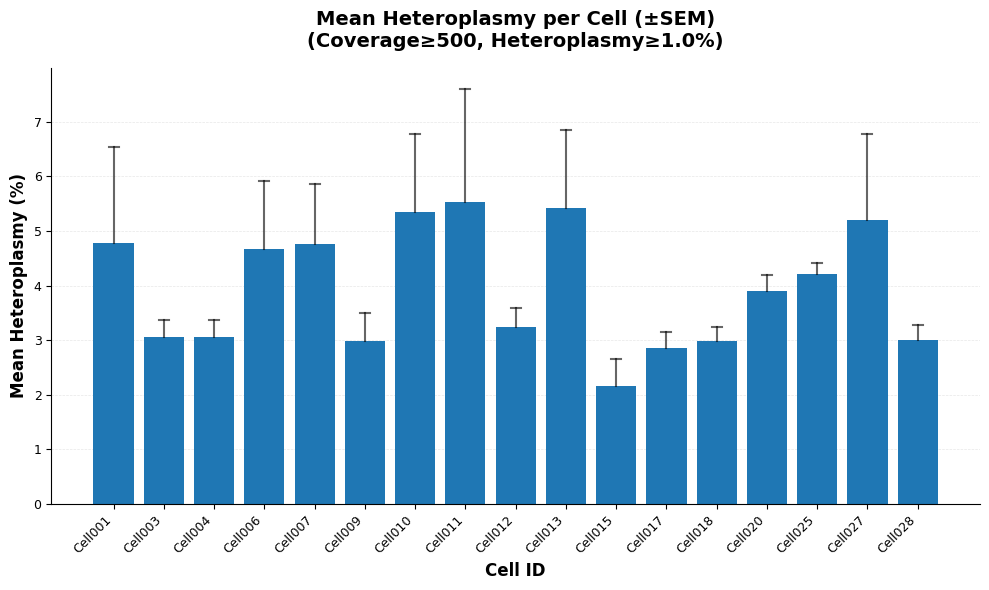

📊 Mean heteroplasmy ranges from 2.17% to 5.53%
📊 Average SEM: 0.82%


In [29]:
# Calculate mean and SEM heteroplasmy per cell (ordered by cell number)
heteroplasmy_stats = df_all.groupby('cell_id', observed=True)['variant_level'].agg(['mean', 'std', 'count'])
heteroplasmy_stats['sem'] = heteroplasmy_stats['std'] / np.sqrt(heteroplasmy_stats['count'])
heteroplasmy_stats = heteroplasmy_stats.sort_index()

# Plot
fig, ax = plt.subplots(figsize=(max(10, len(heteroplasmy_stats) * 0.4), 6))

# Use blue color for all bars
colors = ['#1f77b4'] * len(heteroplasmy_stats)  # All bars blue

bars = ax.bar(
    range(len(heteroplasmy_stats)),
    heteroplasmy_stats['mean'].values,
    color=colors,
    edgecolor='none',
    width=0.8
)

# Add error bars with only top caps
for i, (x, y, sem) in enumerate(zip(range(len(heteroplasmy_stats)), 
                                   heteroplasmy_stats['mean'].values, 
                                   heteroplasmy_stats['sem'].values)):
    # Draw vertical line
    ax.plot([x, x], [y, y + sem], color='black', linewidth=1.5, alpha=0.6)
    # Draw only top cap (horizontal line)
    ax.plot([x - 0.1, x + 0.1], [y + sem, y + sem], color='black', linewidth=1.5, alpha=0.6)

ax.set_title(
    f'Mean Heteroplasmy per Cell (±SEM)\n(Coverage≥{CONFIG["min_coverage"]}, Heteroplasmy≥{CONFIG["min_heteroplasmy"]}%)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Cell ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Heteroplasmy (%)', fontsize=12, fontweight='bold')

ax.set_xticks(range(len(heteroplasmy_stats)))
ax.set_xticklabels(heteroplasmy_stats.index, rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_base']}_mean_heteroplasmy_per_cell.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 Mean heteroplasmy ranges from {heteroplasmy_stats['mean'].min():.2f}% to {heteroplasmy_stats['mean'].max():.2f}%")
print(f"📊 Average SEM: {heteroplasmy_stats['sem'].mean():.2f}%")

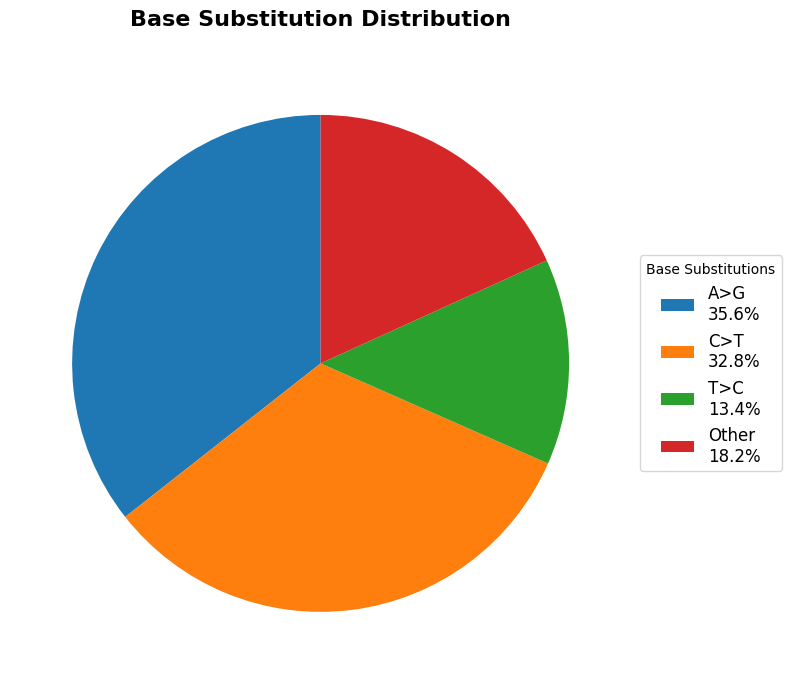

Base Substitution Summary:
  A>G: 35.6%
  C>T: 32.8%
  T>C: 13.4%
  Other: 18.2%
